# K - Nearest Neighbors Classifier


K-Nearest Neighbors (KNN) is a classification algrithm. The central idea is that data points with similar attributes tend to fall into similar categories


Imagine that we have a point named $A$ that needs to classify, the Nearest Neigbors in this are points that are close to $A$; we rely on those points to classify point $A$.  $k$ is the number of points that are closest to $A$ that we need to use. When $k = 3$, we consider the 2 points that are closest to $A$

This is the central idea behind the K-Nearest Neighbor algorithm. If you have a dataset of points where the class of each point is known, you can take a new point with an unknown class, find it's nearest neighbors, and classify it.

## Introduction
We have a dataset of movies. Let's brainstorm some features of a movie data point. Here are some potential features of movie data points:


*   the *length* of the movie in minutes
*   the *budget* of a movie in dollars
*   the *year* of the film's release



In [302]:
# List of movies with features: [length_in_minutes, budget_in_dollars, release_year]
movies = [
    [148, 160000000, 2010],  # Inception
    [175, 6000000, 1972],    # The Godfather
    [136, 63000000, 1999]    # The Matrix
]

for movie in movies:
    print(movie)

[148, 160000000, 2010]
[175, 6000000, 1972]
[136, 63000000, 1999]


## Distance Formula (Euclidean Distance)

First we need to caculate distance between points, the fomular we will use is Euclidean Distance

Suppose we have two points $A$ and $B$ in an $n$-dimensional space:
$A = (a_1, a_2, ..., a_n)$
$B = (b_1, b_2, ..., b_n)$

The distance between $A$ and $B$ is calculated using the following formula:

$$d(A, B) = \sqrt{(a_1 - b_1)^2 + (a_2 - b_2)^2 + ... + (a_n - b_n)^2} = \sqrt{\sum_{i=1}^{n} (a_i - b_i)^2}$$

This formula measures the straight-line distance between two points in any number of dimensions.

In [303]:
def distance(point1, point2):
	squared_difference = 0
	for i in range(len(point1)):
		squared_difference += (point1[i] - point2[i]) ** 2
	final_distance = squared_difference ** 0.5
	return final_distance

In [304]:
print(distance(movies[0], movies[1]))
print(distance(movies[0], movies[2]))

154000000.00000706
97000000.00000136


## We'll implement the three steps of the K-Nearest Neighbor Algorithm:


1.   Normalize the data
2.   Find the $k$ nearest neighbors
3.   Classify the new point based on those neighbors



### 1. Normalize the *data*

When we added the dimension of budget, you might have realized there are some problems with the way our data currently looks.

Consider the two dimensions of release date and budget. The maximum difference between two movies' release dates is about 38 years. However, he difference between two movies' budget can be millions of dollars.

The problem is that the distance formula treats all dimensions equally, regardless of their scale. The budget completely outweighs the importance of all other dimensions because it is on such a huge scale.

The solution to this problem is to normalize the data so every value is between 0 and 1 using min max normalize.

#### Min-Max Normalization Formula

The mathematical formula to normalize a value $x$ in a dataset is:

$$x_{normalized} = \frac{x - min(x)}{max(x) - min(x)}$$

This ensures that all values are scaled between 0 and 1.

In [305]:
#Normalization
def min_max_normalize(lst):
	minimum = min(lst)
	maximum = max(lst)
	normalized = []
	for i in range(len(lst)):
		normalized.append((lst[i] - minimum)/(maximum - minimum))
	return normalized

We import movies dataset and movies label, movie is good which label 1, else label 0

In [306]:
movies_dataset = {
    'Inception': [148, 160000000, 2010],
    'The Godfather': [175, 6000000, 1972],
    'The Matrix': [136, 63000000, 1999],
    'Star Wars': [121, 11000000, 1977],
    'The Dark Knight': [152, 185000000, 2008],
    'Pulp Fiction': [154, 8000000, 1994],
    'Forrest Gump': [142, 55000000, 1994],
    'The Shawshank Redemption': [142, 25000000, 1994],
    'Interstellar': [169, 165000000, 2014],
    'Parasite': [132, 11400000, 2019],
    'The Avengers': [143, 220000000, 2012],
    'Gladiator': [155, 103000000, 2000],
    'Titanic': [194, 200000000, 1997],
    'Seven Samurai': [207, 2000000, 1954],
    'Citizen Kane': [119, 839727, 1941],
    'Spirited Away': [125, 19000000, 2001],
    'Psycho': [109, 806947, 1960],
    'Jurassic Park': [127, 63000000, 1993],
    'The Lion King': [88, 45000000, 1994],
    'Goodfellas': [145, 25000000, 1990],
    'The Silence of the Lambs': [118, 19000000, 1991],
    'The Shining': [146, 19000000, 1980],
    'Blade Runner 2049': [164, 150000000, 2017],
    'Dunkirk': [106, 100000000, 2017],
    'Mad Max: Fury Road': [120, 150000000, 2015],
    'Whiplash': [106, 3300000, 2014],
    'The Social Network': [120, 40000000, 2010],
    'Django Unchained': [165, 100000000, 2012],
    'Fight Club': [139, 63000000, 1999],
    'Arrival': [116, 47000000, 2016]
}

# Movie labels as a dictionary
movie_labels = {
    'Inception': 1, 'The Godfather': 1, 'The Matrix': 1, 'Star Wars': 1,
    'The Dark Knight': 1, 'Pulp Fiction': 1, 'Forrest Gump': 1,
    'The Shawshank Redemption': 1, 'Interstellar': 1, 'Parasite': 1,
    'The Avengers': 1, 'Gladiator': 1, 'Titanic': 1, 'Seven Samurai': 1,
    'Citizen Kane': 1, 'Spirited Away': 1, 'Psycho': 1, 'Jurassic Park': 1,
    'The Lion King': 1, 'Goodfellas': 1, 'The Silence of the Lambs': 1,
    'The Shining': 1, 'Blade Runner 2049': 0, 'Dunkirk': 0,
    'Mad Max: Fury Road': 0, 'Whiplash': 0, 'The Social Network': 0,
    'Django Unchained': 0, 'Fight Club': 1, 'Arrival': 0
}

In [307]:
lengths = [m[0] for m in movies_dataset.values()]
budgets = [m[1] for m in movies_dataset.values()]
years = [m[2] for m in movies_dataset.values()]

n_lengths = min_max_normalize(lengths)
n_budgets = min_max_normalize(budgets)
n_years = min_max_normalize(years)

for i, title in enumerate(movies_dataset.keys()):
  movies_dataset[title] = [n_lengths[i], n_budgets[i], n_years[i]]
print(movies_dataset)

{'Inception': [0.5042016806722689, 0.7262686970284592, 0.8846153846153846], 'The Godfather': [0.7310924369747899, 0.02369168606817115, 0.3974358974358974], 'The Matrix': [0.40336134453781514, 0.2837364238911349, 0.7435897435897436], 'Star Wars': [0.2773109243697479, 0.04650262798246622, 0.46153846153846156], 'The Dark Knight': [0.5378151260504201, 0.8403234065999345, 0.8589743589743589], 'Pulp Fiction': [0.5546218487394958, 0.03281606283388917, 0.6794871794871795], 'Forrest Gump': [0.453781512605042, 0.2472389168282628, 0.6794871794871795], 'The Shawshank Redemption': [0.453781512605042, 0.11037326534249241, 0.6794871794871795], 'Interstellar': [0.680672268907563, 0.7490796389427543, 0.9358974358974359], 'Parasite': [0.3697478991596639, 0.04832750333560982, 1.0], 'The Avengers': [0.46218487394957986, 1.0, 0.9102564102564102], 'Gladiator': [0.5630252100840336, 0.4662239592054954, 0.7564102564102564], 'Titanic': [0.8907563025210085, 0.9087562323428198, 0.717948717948718], 'Seven Samurai'

### 2 Fine the $k$ nearest neighbors

Now that our data has been normalized and we know how to find the distance between two points, we can begin classifying unknown data

To do this, we want to find the $k$ nearest neighbors of the inclassified point.

In [308]:
def classify(unknown, dataset, k):
  distances = []
  for title in dataset:
    dist = distance(unknown, dataset[title])
    distances.append([dist, title])
  distances.sort()
  return distances[:k]

Use test point $(0. 4, 0.2, 0.9)$ and $k = 5$

In [309]:
test_point = [0.4, 0.2, 0.9]
k = 5
neighbors = classify(test_point, movies_dataset, k)
print(f"5 nearest neighbors of test point {test_point}:")
for dist, title in neighbors:
  print(f"- {title}: {dist:.4f}")

5 nearest neighbors of test point [0.4, 0.2, 0.9]:
- The Social Network: 0.1337
- Arrival: 0.1762
- The Matrix: 0.1774
- Fight Club: 0.1797
- Parasite: 0.1842


### 3. Classify the new point based on those neighbors

To classify an unknown data point, we check the labels of its nearest neighbors. The label that appears most frequently determines the classification of that point. We will update classify function



In [310]:
def classify_up(unknown, dataset, k):
  distances = []
  for title in dataset:
    dist = distance(unknown, dataset[title])
    distances.append([dist, title])
  distances.sort()
  neighbors = distances[:k]

  num_good = 0
  num_bad = 0

  for i in range(len(neighbors)):
    title = neighbors[i][1]
    if movie_labels[title] == 1:
      num_good += 1
    else:
      num_bad += 1

  if num_good > num_bad:
    return 1
  else:
    return 0

Now see the prediction of test point

In [311]:
print(classify_up(test_point, movies_dataset, 5))

1



## Visualization of Movie Dataset

To better understand how the KNN algorithm works, we can visualize our normalized dataset in a 3D space. Each axis represents one of our features:
- **X-axis**: Normalized Length
- **Y-axis**: Normalized Budget
- **Z-axis**: Normalized Year

We distinguish between the two classes:
- <span style='color:red'>**Red points**</span>: Good movies (Label 1)
- <span style='color:blue'>**Blue points**</span>: Bad movies (Label 0)
- <span style='color:black'>**Black point**</span>: The unknown movie we are trying to classify (`test_point`)


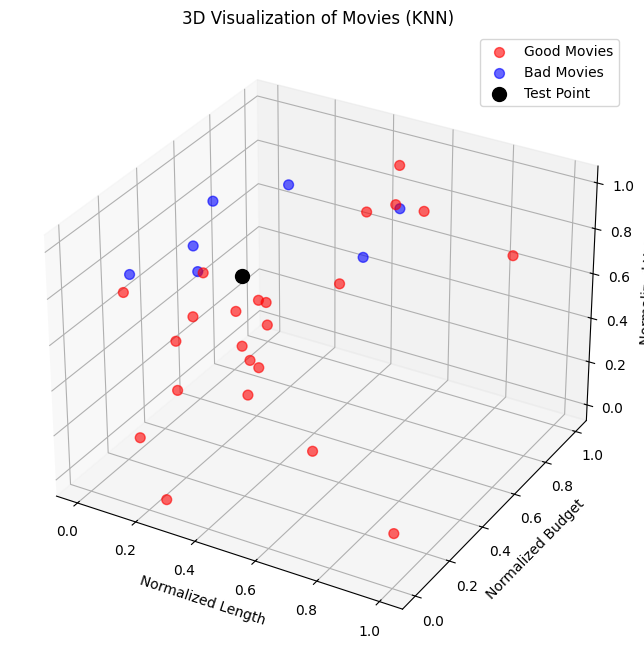

In [312]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x_good, y_good, z_good = [], [], []
x_bad, y_bad, z_bad = [], [], []

for title, features in movies_dataset.items():
  if movie_labels[title] == 1:
      x_good.append(features[0])
      y_good.append(features[1])
      z_good.append(features[2])
  else:
      x_bad.append(features[0])
      y_bad.append(features[1])
      z_bad.append(features[2])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_good, y_good, z_good, c='red', label='Good Movies', s=50, alpha=0.6)
ax.scatter(x_bad, y_bad, z_bad, c='blue', label='Bad Movies', s=50, alpha=0.6)
ax.scatter(test_point[0], test_point[1], test_point[2], c='black', label='Test Point', s=100)

ax.set_xlabel('Normalized Length')
ax.set_ylabel('Normalized Budget')
ax.set_zlabel('Normalized Year')
ax.set_title('3D Visualization of Movies (KNN)')

ax.legend()
plt.show()

## Training and Validation Sets

We're not done yet. We now need to report how effective our algorithm is. Validation accuracy will change dependeing on what K we use.

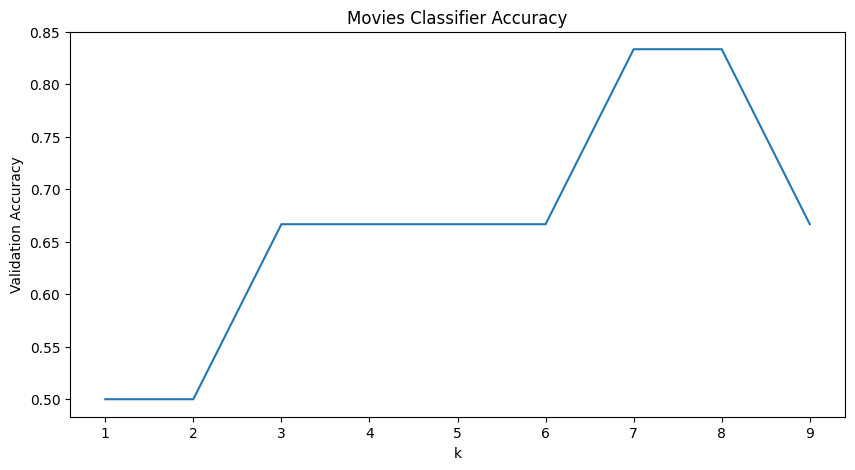

In [313]:
from sklearn.model_selection import train_test_split
import numpy as np

titles = list(movies_dataset.keys())
labels = [movie_labels[t] for t in titles]

# Split
training_set, validation_set, training_labels, validation_labels = train_test_split(
    titles, labels, test_size=0.2, random_state=42
)

training_set = {t: movies_dataset[t] for t in training_set}
validation_set = {t: movies_dataset[t] for t in validation_set}

def find_validation_accuracy(training_set, training_labels, validation_set, validation_labels, k):
  correct = 0
  for t in validation_set:
      predict = classify_up(validation_set[t], training_set, k)
      if predict == movie_labels[t]:
          correct += 1
  return correct / len(validation_set)

k_range = range(1, 10)
accuraces = []
for i in range(1, 10):
  accuraces.append(find_validation_accuracy(training_set, training_labels, validation_set, validation_labels, i))

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(k_range, accuraces)
plt.title("Movies Classifier Accuracy")
plt.xlabel("k")
plt.ylabel("Validation Accuracy")
plt.show()

In [314]:
max_acc = max(accuraces)
print(f"Max accuracy: {max_acc * 100:.2f}%")



Max accuracy: 83.33%
